In [29]:
# Shyla Agrawal
# 7/22/26
# Monte Carlos code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import odlib


In [30]:
# LSPR plate solves and sigmas
obs1_coefficients = odlib.compute_coefficients("reference_stars_1.csv")
obs2_coefficients = odlib.compute_coefficients("reference_stars_2.csv")
obs3_coefficients = odlib.compute_coefficients("reference_stars_3.csv")

obs1_star_positions = pd.read_csv("reference_stars_1.csv")
obs2_star_positions = pd.read_csv("reference_stars_2.csv")
obs3_star_positions = pd.read_csv("reference_stars_3.csv")

sigma_ra1, sigma_dec1 = odlib.compute_sigmas(obs1_coefficients, obs1_star_positions)
sigma_ra2, sigma_dec2 = odlib.compute_sigmas(obs2_coefficients, obs2_star_positions)
sigma_ra3, sigma_dec3 = odlib.compute_sigmas(obs3_coefficients, obs3_star_positions)

data = pd.read_csv("mog_test_cases.csv")

t1 = data["t1_jd"].iloc[0]
t2 = data["t2_jd"].iloc[0]
t3 = data["t3_jd"].iloc[0]

ra1_deg, dec1_deg = odlib.radec_to_decimal(data["ra1"].iloc[0], data["dec1"].iloc[0])
ra2_deg, dec2_deg = odlib.radec_to_decimal(data["ra2"].iloc[0], data["dec2"].iloc[0])
ra3_deg, dec3_deg = odlib.radec_to_decimal(data["ra3"].iloc[0], data["dec3"].iloc[0])

R1 = np.array([data["sun_x_1"].iloc[0], data["sun_y_1"].iloc[0], data["sun_z_1"].iloc[0]])
R2 = np.array([data["sun_x_2"].iloc[0], data["sun_y_2"].iloc[0], data["sun_z_2"].iloc[0]])
R3 = np.array([data["sun_x_3"].iloc[0], data["sun_y_3"].iloc[0], data["sun_z_3"].iloc[0]])
R1 = odlib.ecliptic_to_equatorial(R1)
R2 = odlib.ecliptic_to_equatorial(R2)
R3 = odlib.ecliptic_to_equatorial(R3)

seed = 1982
N_samples = 10000
a, e, i, Om, om, M = [], [], [], [], [], []

In [31]:
for _ in range(N_samples):
    np.random.seed(seed)

    # for each ra dec value sampling c random noise number sigma from lspr
    noise_ra1 = np.random.normal(loc=0, scale=sigma_ra1)
    noise_dec1 = np.random.normal(loc=0, scale=sigma_dec1)
    noise_ra2 = np.random.normal(loc=0, scale=sigma_ra2)
    noise_dec2 = np.random.normal(loc=0, scale=sigma_dec2)
    noise_ra3 = np.random.normal(loc=0, scale=sigma_ra3)
    noise_dec3 = np.random.normal(loc=0, scale=sigma_dec3)

    # create new input (observation + noise)
    ra1_new_deg = ra1_deg + noise_ra1
    dec1_new_deg = dec1_deg + noise_dec1
    ra2_new_deg = ra2_deg + noise_ra2
    dec2_new_deg = dec2_deg + noise_dec2
    ra3_new_deg = ra3_deg + noise_ra3
    dec3_new_deg = dec3_deg + noise_dec3

    ra1_new, dec1_new = odlib.decimal_to_radec(ra1_new_deg, dec1_new_deg)
    ra2_new, dec2_new = odlib.decimal_to_radec(ra2_new_deg, dec2_new_deg)
    ra3_new, dec3_new = odlib.decimal_to_radec(ra3_new_deg, dec3_new_deg)

    r2, v2 = odlib.gauss_method(
        t1, t2, t3,
        ra1_new, dec1_new,
        ra2_new, dec2_new,
        ra3_new, dec3_new,
        R1, R2, R3
    )

    r2 = odlib.equatorial_to_ecliptic(r2)
    v2 = odlib.equatorial_to_ecliptic(v2)

    a_val, e_val, i_val, Om_val, om_val, M_val = odlib.orbital_elements(r2, v2)

    a.append(a_val)
    e.append(e_val)
    i.append(i_val)
    Om.append(Om_val)
    om.append(om_val)
    M.append(M_val)


    # seed += 1
    seed += 1

# report the mean and the uncertainty
print("\nMonte Carlo Results:")
print("----------------------------------------")
print(f"a (AU)      : {np.mean(a):12.6f} +/- {np.std(a, ddof=1):10.6f}")
print(f"e           : {np.mean(e):12.6f} +/- {np.std(e, ddof=1):10.6f}")
print(f"i (deg)     : {np.mean(i):12.6f} +/- {np.std(i, ddof=1):10.6f}")
print(f"Omega (deg) : {np.mean(Om):12.6f} +/- {np.std(Om, ddof=1):10.6f}")
print(f"omega (deg) : {np.mean(om):12.6f} +/- {np.std(om, ddof=1):10.6f}")
print(f"M (deg)     : {np.mean(M):12.6f} +/- {np.std(M, ddof=1):10.6f}")
print("----------------------------------------")


Monte Carlo Results:
----------------------------------------
a (AU)      :     2.589797 +/-   0.000478
e           :     0.393726 +/-   0.000059
i (deg)     :    27.114317 +/-   0.007384
Omega (deg) :   217.917409 +/-   0.012337
omega (deg) :   113.707731 +/-   0.026673
M (deg)     :   337.946216 +/-   0.006208
----------------------------------------


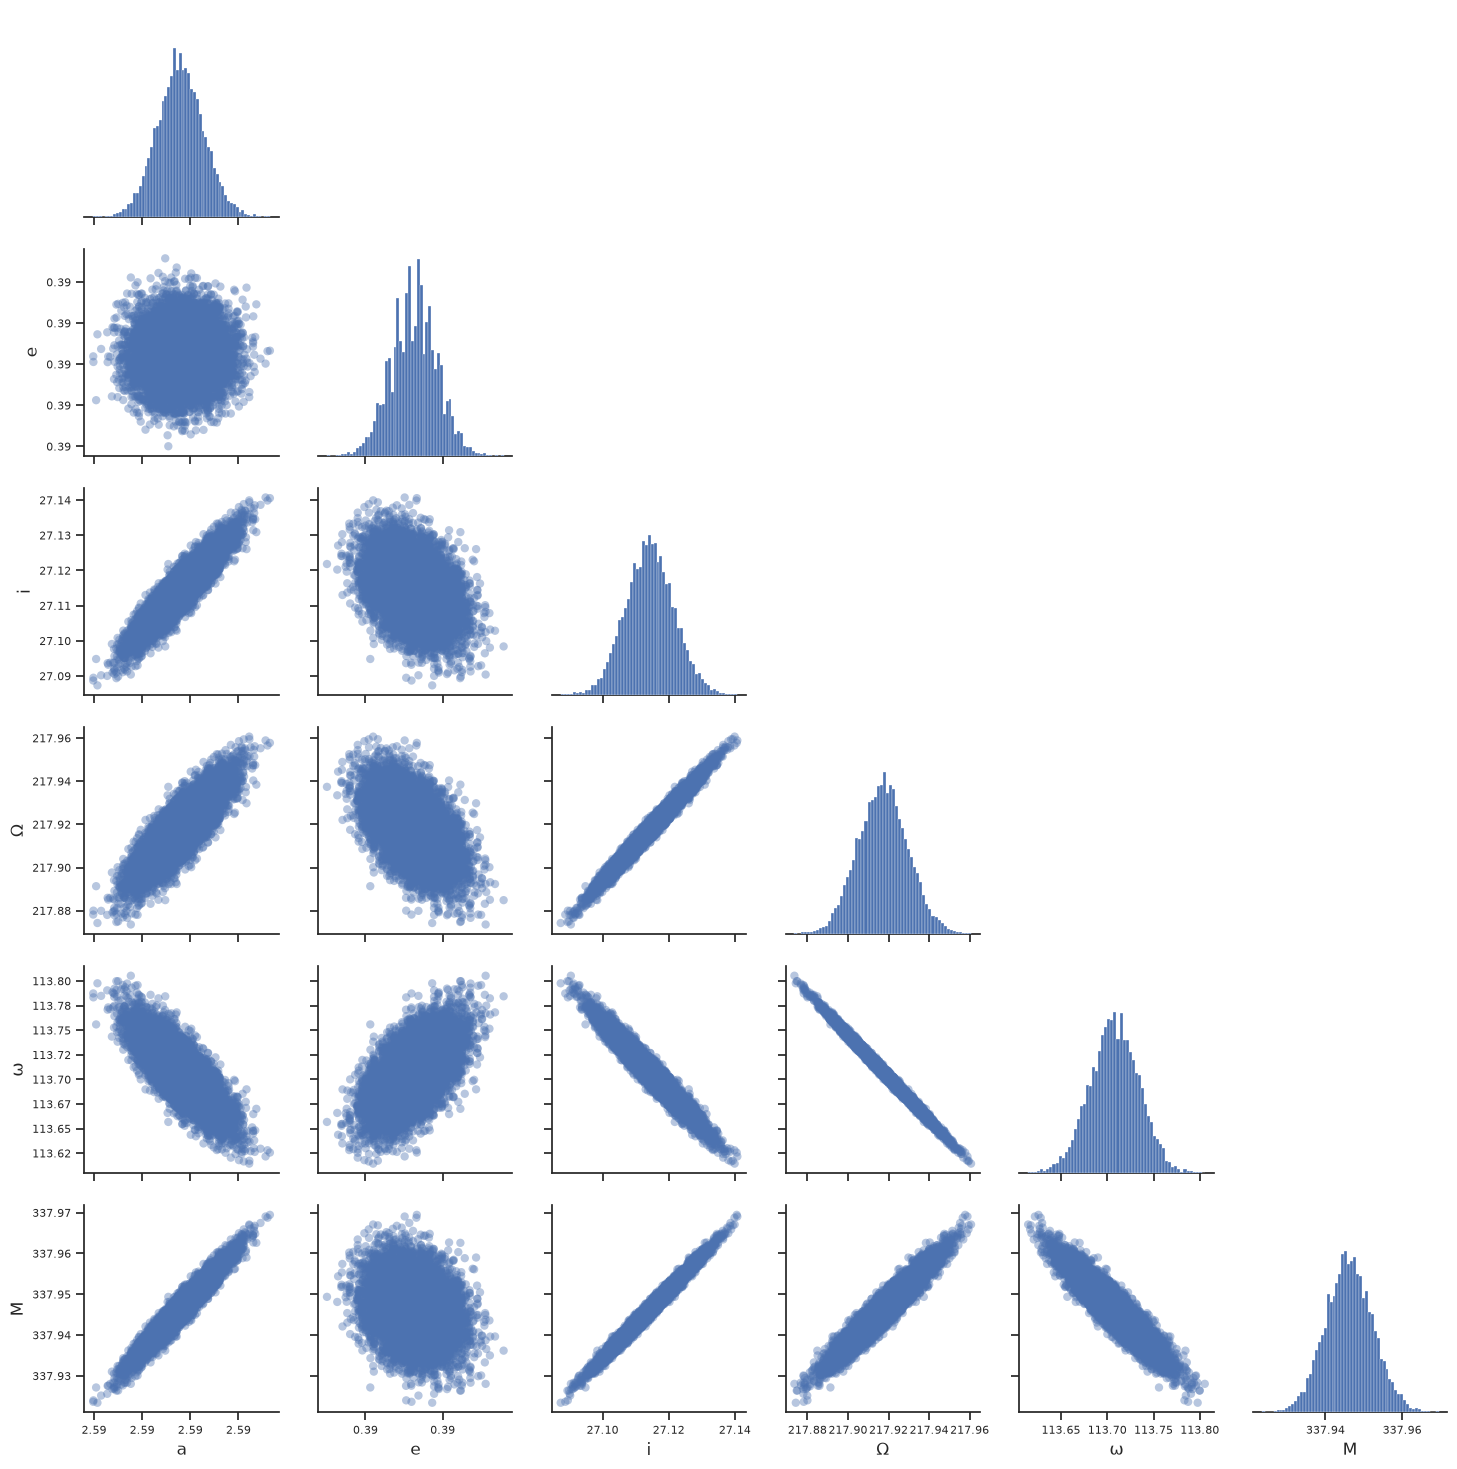

In [32]:
labels = ["a", "e", "i", "Ω", "ω", "M"]
param_data = [a, e, i, Om, om, M]

sns.set_theme(style="ticks", font_scale=1.0)

df = pd.DataFrame({labels[k]: param_data[k] for k in range(len(labels))})

g = sns.pairplot(df, corner=True, plot_kws=dict(edgecolor="none", alpha=0.4), diag_kws=dict(alpha=1))

means = {labels[k]: np.mean(param_data[k]) for k in range(len(labels))}

for i, yvar in enumerate(g.y_vars):
    for j, xvar in enumerate(g.x_vars):
        ax = g.axes[i, j]
        if ax is not None:
            ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            ax.tick_params(axis='both', labelsize=8)
            #ax.axvline(means[xvar], color="red", linestyle="--", linewidth=1.5)
            #if i != j:
                #ax.axhline(means[yvar], color="red", linestyle="--", linewidth=1.5)

plt.show()